# 读取数据

## read_table

### 薯条订单  
这个数据集中数据都是用空格（分隔符）隔开  
因为 read_table 默认的分隔符就是制表符（sep='\t'），所以可以直接读取  
bitly短网址：[http://bit.ly/chiporders] 

In [2]:
import pandas as pd
data_chipotle = pd.read_table('chipotle.tsv')
data_chipotle

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


#### 显示首末5行

In [3]:
data_chipotle.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [4]:
data_chipotle.tail()

,order_id,quantity,item_name,choice_description,item_price
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75
4621,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$8.75


#### 显示数据集的行列维度

In [5]:
data_chipotle.shape

(4622, 5)

#### 改变显示行列数  
通过设置pandas的参数，可以临时或永久地改变DataFrame的显示方式  

import pandas as pd  

#设置显示的最大行数为None（即显示所有行）  
pd.set_option('display.max_rows', None)  

#设置显示的最大列数为None（即显示所有列）  
pd.set_option('display.max_columns', None)  

#设置每列的最大宽度，使单元格内容完整显示（-1代表不截断）  
pd.set_option('display.max_colwidth', -1)  

#设置显示宽度，避免换行  
pd.set_option('display.width', None)  

#设置完成后，再次输入变量名data运行，即可看到完整表格，你可以通过滚动来浏览所有行。如果想恢复默认设置，可以使用  pd.reset_option("display.max_rows")  

#### 精准搜索  
如果知道要查找的项属于哪一列，或者知道大概的值，用代码直接筛选是最高效的，无需显示全部数据。  

#例如，在'item_name'列中查找包含'Chicken Bowl'的所有行  
data[data['item_name'].str.contains('Chicken Bowl', na=False)]  

#或者根据行号查看特定范围的数据（例如查看第1000到1010行）  
data.iloc[1000:1010]  

#### 临时更改显示选项  
如果你只想在查看某个特定表格时临时显示完整内容，而不影响全局设置，可以使用option_context    

with pd.option_context('display.max_rows', None, 'display.max_columns', None):    
    display(data)  # 或者使用 print(data)    

### 电影用户  
原始数据集短网址：bit.ly/movieusers    
- 这个数据集里面各个数据都是用｜来分开的，如果用上述的读法会全部挤在一个单元格里  
  故要在读取时指明制表符的类型（sep=‘｜’），将其作为参数传给读取函数  
  另外：制表符也可能是逗号之类的
- 这个数据集也是没有列命名的，薯条数据的首行是各列的名称，这里如不指明会把第一行有效数据误认为是命名  
  这一点也要传参

可以尝试不传sep、header会生成什么样的表格

In [6]:
data_movieuser = pd.read_table('movieuser.txt',sep = '|',header = None)
data_movieuser

,0,1,2,3,4
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


#### 为各列取名  
运用python的列表

In [7]:
col_name = ['ID','Age','Gender','Occupation','Revenue']
data_movieuser = pd.read_table('movieuser.txt',sep = '|',header = None,names = col_name)
data_movieuser 

,ID,Age,Gender,Occupation,Revenue
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


## read_csv

### 电影评分  
读取的电影评分csv文件的短网址为：http://bit.ly/imdbratings  
注意这里的制表符全是逗号  

In [8]:
import pandas as pd
data_imdbratings = pd.read_csv('imdbratings.csv')
data_imdbratings

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [9]:
# 如果使用read_table只要写明sep的类型也可以得到相同的读表结果
data_imdbratings_2 = pd.read_table('imdbratings.csv',sep = ',')
data_imdbratings_2

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


# 数据类型：Series & DataFrame  
Series：序列，指 pandas 中的一列数据，可以理解为带标签的一维数组。通常是一列相同数据类型的项  
DataFrame：数据框/帧，指由多个序列组成的二维表格数据结构。一个数据集存在一个数据框中，通常由几列不同数据类型的series组成  

## 提取Series的三种方法

In [10]:
# 方法一
data_movieuser.Age

# 方法二
# data_movieuser['Age']

# 方法三：打出data.之后长按Tab键会自动跳出选项菜单，选中即可，不需要打出具体的列标签名称
# data_movieuser.

0      24
1      53
2      23
3      24
4      33
       ..
938    26
939    32
940    20
941    48
942    22
Name: Age, Length: 943, dtype: int64

## 读取数据类型

In [11]:
# 显示data的数据类型
type(data_movieuser)

pandas.DataFrame

In [12]:
# 读取某一Series的数据类型
type(data_movieuser.Age)

pandas.Series

# 基本操作

## 合并、生成新列  

### 同类型直接相加  
- 数字+数字/字符串+字符串 可行
- 数字+字符串 不可行

In [13]:
# data.new = data.Occupation + data.Revenue
# 报错：1、类型不一致 2、增加新列时data.new不会显示，要用data['new']

data_movieuser['new1'] = data_movieuser.Gender + data_movieuser.Occupation
data_movieuser['new2'] = data_movieuser.ID + data_movieuser.Age
data_movieuser

,ID,Age,Gender,Occupation,Revenue,new1,new2
0,1,24,M,technician,85711,Mtechnician,25
1,2,53,F,other,94043,Fother,55
2,3,23,M,writer,32067,Mwriter,26
3,4,24,M,technician,43537,Mtechnician,28
4,5,33,F,other,15213,Fother,38
...,...,...,...,...,...,...,...
938,939,26,F,student,33319,Fstudent,965
939,940,32,M,administrator,02215,Madministrator,972
940,941,20,M,student,97229,Mstudent,961
941,942,48,F,librarian,78209,Flibrarian,990


### 不同类转化为str  
astype(str)可以将所选series全部转化为str类型，该列如果是混合类型也会全部转化

In [14]:
data_movieuser['new3'] = data_movieuser.Age.astype(str) + '-' + data_movieuser.Gender
data_movieuser

,ID,Age,Gender,Occupation,Revenue,new1,new2,new3
0,1,24,M,technician,85711,Mtechnician,25,24-M
1,2,53,F,other,94043,Fother,55,53-F
2,3,23,M,writer,32067,Mwriter,26,23-M
3,4,24,M,technician,43537,Mtechnician,28,24-M
4,5,33,F,other,15213,Fother,38,33-F
...,...,...,...,...,...,...,...,...
938,939,26,F,student,33319,Fstudent,965,26-F
939,940,32,M,administrator,02215,Madministrator,972,32-M
940,941,20,M,student,97229,Mstudent,961,20-M
941,942,48,F,librarian,78209,Flibrarian,990,48-F


## describe函数-描述性统计信息

### 数值型describe  
对于所有数值型的列（数值型序列），它会输出数据的描述性统计信息，包括  
- 计数、均值、标准差、最小值、25%分位数、50%分位数（中位数）、75%分位数和最大值

In [15]:
# 以csv电影评分文件为例,这个文件里面只有两个数值型列：评分、时长
data_imdbratings.describe()

,star_rating,duration
count,979.000000,979.000000
mean,7.889785,120.979571
std,0.336069,26.218010
min,7.400000,64.000000
25%,7.600000,102.000000
50%,7.800000,117.000000
75%,8.100000,134.000000
max,9.300000,242.000000


### str型describe  
在 pandas 中，所有字符串值都是 **object** 类型  
在describe函数中加上参数 include='object'，则会产生以下效果：  
- 所有str列都会输出但指标少了很多，只显示那些适用于字符串的指标     
- count：非缺失值（非NaN）的数量，统计了这一列字符串数据中，有多少个单元格是有效值（不为空），排除了缺失值  
- unique：唯一值的数量，一共有多少种不同的字符串。eg.100行数据只有“是/否”两种可能，那么unique的值就是2。这个指标反映了数据的多样性  
- top：出现频率最高的字符串，即众数。如果有多个并列最高的，pandas通常返回它遇到的第一个。
- freq：出现频率最高的字符串（即top）的出现次数。它与top是成对出现的    
- 总结：count 告诉你总共有多少有效信息，unique 告诉你信息有多丰富，而 top 和 freq 则一起告诉你最常见的信息是什么以及它有多常见。  

In [16]:
data_imdbratings.describe(include='object')

/var/folders/bj/70fhs5ln529bp1y98kmxbgg40000gn/T/ipykernel_13278/2870015710.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_imdbratings.describe(include='object')


,title,content_rating,genre,actors_list
count,979,976,979,979
unique,975,12,16,969
top,The Girl with the Dragon Tattoo,R,Drama,"[u'Daniel Radcliffe', u'Emma Watson', u'Rupert..."
freq,2,460,278,6


## dtypes函数-检查数据的类型属性
使用 data.dtypes 检查数据的类型属性

In [17]:
data_imdbratings.dtypes

star_rating       float64
title                 str
content_rating        str
genre                 str
duration            int64
actors_list           str
dtype: object

## 易错注意点：关于括号  
与Python 内部的设计方式有关  
- 有些地方不带括号（如 dtypes），不带括号的是属性（property），是直接获取值  
- 有些地方带括号（如 describe()），带括号的是函数（method），函数是调用一个方法，可以传入参数并执行一些代码  

非常有用的技巧分享：  
1. 把光标放在一个函数上，按一次 Shift+Tab，会显示该函数的简要描述，包括可以传入哪些参数。之前用了include=None，默认是 None，当我们传入值时，默认的 None 就被 object 替换了。  
2. 再按一次 Ctrl+Tab（或 Shift+Tab），你会得到更详细的函数说明。如果再按一次，第三次按 Shift+Tab 时，这个提示框会固定在那里，不会轻易消失。第四次按 Shift+Tab，它会以独立窗口的形式显示。你可以根据需要把它拖出来或者仔细查看。当你遇到一个新函数，想知道可以传入哪些参数时，这个功能非常实用。

## columns列标签

### 输出列标签

In [18]:
# 以csv电影评分为例

data_imdbratings.columns
# 生成一个包含所有列名的列表，以及它们的数据类型object

Index(['star_rating', 'title', 'content_rating', 'genre', 'duration',
       'actors_list'],
      dtype='str')

### rename函数-重命名列标签

#### 单个重命名

In [19]:
# 将列标签star_rating临时修改为StarRating
data_imdbratings.rename( columns = {'star_rating' : 'StarRating'} )

,StarRating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [20]:
# 注意，此时打印全数据框仍然保持旧的列标签命名，其底层未被修改
data_imdbratings

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [21]:
# 从底层彻底重命名应补充inplace=True
# 注意 True 大写首字母变色后才是正确的
data_imdbratings.rename( columns = {'star_rating' : 'StarRating'} ,inplace = True)
data_imdbratings

,StarRating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


#### 多个不规律重命名

In [22]:
# python列表简化重命名（适用于有限可操作的columns个数，且重命名格式不统一）

# 将想要的多个列标签命名写在一个python列表中
data_col = ['StarRating','Title','ContentRating','Genre','Duration','ActorsList']

# 方法一：将列表赋值给columns
data_imdbratings.columns = data_col
data_imdbratings

# 方法二：读取表格时就重命名，详见读取数据板块笔记

,StarRating,Title,ContentRating,Genre,Duration,ActorsList
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


#### 多个规律化重命名

In [23]:
# str库简化重命名（适用columns个数过多，且重命名格式较为统一）

import pandas as pd
data_imdbratings = pd.read_csv('imdbratings.csv')

# replace 属于str库，不适用于object类型的列标签，故先由object转化为str
# 这里把所有的'_'去掉

data_imdbratings.columns = data_imdbratings.columns.str.replace('_','')
data_imdbratings

,starrating,title,contentrating,genre,duration,actorslist
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


## drop函数——删除行/列

In [24]:
import pandas as pd
data_imdbratings = pd.read_csv('imdbratings.csv')

# axis = 1表示删去的是列，axis = 0表示删去的是行
# 这里表示删去列名为title的列
data_imdbratings.drop('title',axis = 1,inplace = True)
data_imdbratings

,star_rating,content_rating,genre,duration,actors_list
0,9.3,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...
974,7.4,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [25]:
# 同时删去两列，此时传参要传目标列名构成的列表
data_imdbratings.drop(['genre','duration'],axis = 1,inplace = True)
data_imdbratings

,star_rating,content_rating,actors_list
0,9.3,R,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,R,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,R,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,PG-13,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,R,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...
974,7.4,PG,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,PG,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,PG-13,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,PG,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [26]:
# 同时删去三行
data_imdbratings.drop([0,1,2],axis = 0, inplace = True)
data_imdbratings

,star_rating,content_rating,actors_list
3,9.0,PG-13,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,R,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
5,8.9,NOT RATED,"[u'Henry Fonda', u'Lee J. Cobb', u'Martin Bals..."
6,8.9,NOT RATED,"[u'Clint Eastwood', u'Eli Wallach', u'Lee Van ..."
7,8.9,PG-13,"[u'Elijah Wood', u'Viggo Mortensen', u'Ian McK..."
...,...,...,...
974,7.4,PG,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,PG,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,PG-13,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,PG,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


## sort_values函数-排序

### 单列排序

In [27]:
import pandas as pd
data_imdbratings = pd.read_csv('imdbratings.csv')

# 仅在查询时显示单个series的升序排列，实际的DataFrame没有改变
data_imdbratings['duration'].sort_values()

389     64
338     66
258     67
88      68
293     68
      ... 
445    220
142    224
78     229
157    238
476    242
Name: duration, Length: 979, dtype: int64

In [28]:
# 传入参数ascending=False可得降序排列
data_imdbratings['duration'].sort_values(ascending=False)

476    242
157    238
78     229
142    224
445    220
      ... 
293     68
88      68
258     67
338     66
389     64
Name: duration, Length: 979, dtype: int64

### 全框单列排序

In [29]:
# 根据duration的升序重新排布全框
data_imdbratings.sort_values('duration')

,star_rating,title,content_rating,genre,duration,actors_list
389,8.0,Freaks,UNRATED,Drama,64,"[u'Wallace Ford', u'Leila Hyams', u'Olga Bacla..."
338,8.0,Battleship Potemkin,UNRATED,History,66,"[u'Aleksandr Antonov', u'Vladimir Barsky', u'G..."
258,8.1,The Cabinet of Dr. Caligari,UNRATED,Crime,67,"[u'Werner Krauss', u'Conrad Veidt', u'Friedric..."
88,8.4,The Kid,NOT RATED,Comedy,68,"[u'Charles Chaplin', u'Edna Purviance', u'Jack..."
293,8.1,Duck Soup,PASSED,Comedy,68,"[u'Groucho Marx', u'Harpo Marx', u'Chico Marx']"
...,...,...,...,...,...,...
445,7.9,The Ten Commandments,APPROVED,Adventure,220,"[u'Charlton Heston', u'Yul Brynner', u'Anne Ba..."
142,8.3,Lagaan: Once Upon a Time in India,PG,Adventure,224,"[u'Aamir Khan', u'Gracy Singh', u'Rachel Shell..."
78,8.4,Once Upon a Time in America,R,Crime,229,"[u'Robert De Niro', u'James Woods', u'Elizabet..."
157,8.2,Gone with the Wind,G,Drama,238,"[u'Clark Gable', u'Vivien Leigh', u'Thomas Mit..."


In [30]:
# 根据duration的降序重新排布全框
data_imdbratings.sort_values('duration', ascending = False)

,star_rating,title,content_rating,genre,duration,actors_list
476,7.8,Hamlet,PG-13,Drama,242,"[u'Kenneth Branagh', u'Julie Christie', u'Dere..."
157,8.2,Gone with the Wind,G,Drama,238,"[u'Clark Gable', u'Vivien Leigh', u'Thomas Mit..."
78,8.4,Once Upon a Time in America,R,Crime,229,"[u'Robert De Niro', u'James Woods', u'Elizabet..."
142,8.3,Lagaan: Once Upon a Time in India,PG,Adventure,224,"[u'Aamir Khan', u'Gracy Singh', u'Rachel Shell..."
445,7.9,The Ten Commandments,APPROVED,Adventure,220,"[u'Charlton Heston', u'Yul Brynner', u'Anne Ba..."
...,...,...,...,...,...,...
293,8.1,Duck Soup,PASSED,Comedy,68,"[u'Groucho Marx', u'Harpo Marx', u'Chico Marx']"
88,8.4,The Kid,NOT RATED,Comedy,68,"[u'Charles Chaplin', u'Edna Purviance', u'Jack..."
258,8.1,The Cabinet of Dr. Caligari,UNRATED,Crime,67,"[u'Werner Krauss', u'Conrad Veidt', u'Friedric..."
338,8.0,Battleship Potemkin,UNRATED,History,66,"[u'Aleksandr Antonov', u'Vladimir Barsky', u'G..."


### 全框多列排序

In [31]:
# 先按照genre的字母升序排列，genre相同的情况下按duration升序排列
data_imdbratings.sort_values(['genre','duration'])

,star_rating,title,content_rating,genre,duration,actors_list
533,7.8,Run Lola Run,R,Action,80,"[u'Franka Potente', u'Moritz Bleibtreu', u'Her..."
633,7.7,The Warriors,R,Action,92,"[u'Michael Beck', u'James Remar', u'Dorsey Wri..."
455,7.9,Taken,PG-13,Action,93,"[u'Liam Neeson', u'Maggie Grace', u'Famke Jans..."
685,7.7,First Blood,R,Action,93,"[u'Sylvester Stallone', u'Brian Dennehy', u'Ri..."
744,7.6,Mad Max 2: The Road Warrior,R,Action,94,"[u'Mel Gibson', u'Bruce Spence', u'Michael Pre..."
...,...,...,...,...,...,...
421,7.9,The Outlaw Josey Wales,PG,Western,135,"[u'Clint Eastwood', u'Sondra Locke', u'Chief D..."
263,8.1,Rio Bravo,NOT RATED,Western,141,"[u'John Wayne', u'Dean Martin', u'Ricky Nelson']"
6,8.9,"The Good, the Bad and the Ugly",NOT RATED,Western,161,"[u'Clint Eastwood', u'Eli Wallach', u'Lee Van ..."
59,8.5,Django Unchained,R,Western,165,"[u'Jamie Foxx', u'Christoph Waltz', u'Leonardo..."


In [32]:
# 先按照genre的字母升序排列，genre相同的情况下按duration降序排列
data_imdbratings.sort_values(by=['genre', 'duration'], ascending=[True, False])

,star_rating,title,content_rating,genre,duration,actors_list
767,7.6,"It's a Mad, Mad, Mad, Mad World",APPROVED,Action,205,"[u'Spencer Tracy', u'Milton Berle', u'Ethel Me..."
385,8.0,Spartacus,PG-13,Action,197,"[u'Kirk Douglas', u'Laurence Olivier', u'Jean ..."
671,7.7,Grindhouse,R,Action,191,"[u'Kurt Russell', u'Rose McGowan', u'Danny Tre..."
534,7.8,The Longest Day,G,Action,178,"[u'John Wayne', u'Robert Ryan', u'Richard Burt..."
82,8.4,Braveheart,R,Action,177,"[u'Mel Gibson', u'Sophie Marceau', u'Patrick M..."
...,...,...,...,...,...,...
421,7.9,The Outlaw Josey Wales,PG,Western,135,"[u'Clint Eastwood', u'Sondra Locke', u'Chief D..."
107,8.3,For a Few Dollars More,APPROVED,Western,132,"[u'Clint Eastwood', u'Lee Van Cleef', u'Gian M..."
119,8.3,Unforgiven,R,Western,131,"[u'Clint Eastwood', u'Gene Hackman', u'Morgan ..."
704,7.6,High Plains Drifter,R,Western,105,"[u'Clint Eastwood', u'Verna Bloom', u'Marianna..."


## sort_index函数-按行标签排序

In [33]:
import pandas as pd

# Create a DataFrame with unsorted index
df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6]
}, index=['c', 'a', 'b'])

print("Original DataFrame:")
print(df)
#    A  B
# c  1  4
# a  2  5
# b  3  6

# Sort by index labels
df_sorted = df.sort_index()

print("\nSorted by index:")
print(df_sorted)
#    A  B
# a  2  5
# b  3  6
# c  1  4

Original DataFrame:
   A  B
c  1  4
a  2  5
b  3  6

Sorted by index:
   A  B
a  2  5
b  3  6
c  1  4


# 数据筛选&切片

## 筛选DataFrame

### 单条件筛选

In [34]:
# choose rows with duration >= 175 in imdbratings
# WAY 1:for loop
import pandas as pd
data_imdbratings = pd.read_csv('imdbratings.csv')

booleans = []  # define a new empty bool list
for lenth in data_imdbratings.duration: # let every different duration = length 
    if lenth >= 175: 
        booleans.append(True)  # add a new bool value in the list
    else:
        booleans.append(False) # add a new bool value in the list

# when the loop finish, booleans become a list with true/false
data_imdbratings[booleans] # filter out rows with booleans = true

,star_rating,title,content_rating,genre,duration,actors_list
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
7,8.9,The Lord of the Rings: The Return of the King,PG-13,Adventure,201,"[u'Elijah Wood', u'Viggo Mortensen', u'Ian McK..."
8,8.9,Schindler's List,R,Biography,195,"[u'Liam Neeson', u'Ralph Fiennes', u'Ben Kings..."
10,8.8,The Lord of the Rings: The Fellowship of the Ring,PG-13,Adventure,178,"[u'Elijah Wood', u'Ian McKellen', u'Orlando Bl..."
14,8.8,The Lord of the Rings: The Two Towers,PG-13,Adventure,179,"[u'Elijah Wood', u'Ian McKellen', u'Viggo Mort..."
17,8.7,Seven Samurai,UNRATED,Drama,207,"[u'Toshir\xf4 Mifune', u'Takashi Shimura', u'K..."
26,8.6,Once Upon a Time in the West,PG-13,Western,175,"[u'Henry Fonda', u'Charles Bronson', u'Claudia..."
40,8.5,The Green Mile,R,Crime,189,"[u'Tom Hanks', u'Michael Clarke Duncan', u'Dav..."
78,8.4,Once Upon a Time in America,R,Crime,229,"[u'Robert De Niro', u'James Woods', u'Elizabet..."


In [35]:
# WAY 2: Vectorized operations in pandas 

data_imdbratings[data_imdbratings.duration >= 175]

# data_imdbratings.duration >= 175 
# it means that we campare a series with a number 175,and the result is a bool series with True/False
# so we can say [data_imdbratings.duration >= 175] = [booleans]

,star_rating,title,content_rating,genre,duration,actors_list
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
7,8.9,The Lord of the Rings: The Return of the King,PG-13,Adventure,201,"[u'Elijah Wood', u'Viggo Mortensen', u'Ian McK..."
8,8.9,Schindler's List,R,Biography,195,"[u'Liam Neeson', u'Ralph Fiennes', u'Ben Kings..."
10,8.8,The Lord of the Rings: The Fellowship of the Ring,PG-13,Adventure,178,"[u'Elijah Wood', u'Ian McKellen', u'Orlando Bl..."
14,8.8,The Lord of the Rings: The Two Towers,PG-13,Adventure,179,"[u'Elijah Wood', u'Ian McKellen', u'Viggo Mort..."
17,8.7,Seven Samurai,UNRATED,Drama,207,"[u'Toshir\xf4 Mifune', u'Takashi Shimura', u'K..."
26,8.6,Once Upon a Time in the West,PG-13,Western,175,"[u'Henry Fonda', u'Charles Bronson', u'Claudia..."
40,8.5,The Green Mile,R,Crime,189,"[u'Tom Hanks', u'Michael Clarke Duncan', u'Dav..."
78,8.4,Once Upon a Time in America,R,Crime,229,"[u'Robert De Niro', u'James Woods', u'Elizabet..."


### 多条件筛选

In [36]:
# filter out R & Crime films

data_imdbratings[(data_imdbratings.content_rating == 'R') & (data_imdbratings.genre == 'Crime')]

# '&' means and,'|' means or
# str should be shown with ''
# '=' and '=='have different means

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
21,8.7,City of God,R,Crime,130,"[u'Alexandre Rodrigues', u'Matheus Nachtergael..."
...,...,...,...,...,...,...
927,7.5,Brick,R,Crime,110,"[u'Joseph Gordon-Levitt', u'Lukas Haas', u'Emi..."
931,7.4,Mean Streets,R,Crime,112,"[u'Robert De Niro', u'Harvey Keitel', u'David ..."
950,7.4,Bound,R,Crime,108,"[u'Jennifer Tilly', u'Gina Gershon', u'Joe Pan..."
969,7.4,Law Abiding Citizen,R,Crime,109,"[u'Gerard Butler', u'Jamie Foxx', u'Leslie Bibb']"


### isin函数-简化多条件判断语句

In [37]:
# if genre is in the list ['Crime','Action','Western'],then bool be True
# else bool be false

data_imdbratings.genre.isin(['Crime','Action','Western'])

0       True
1       True
2       True
3       True
4       True
       ...  
974    False
975    False
976     True
977    False
978     True
Name: genre, Length: 979, dtype: bool

In [38]:
data_imdbratings[data_imdbratings.genre.isin(['Crime','Action','Western'])]

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
963,7.4,La Femme Nikita,R,Action,118,"[u'Anne Parillaud', u'Marc Duret', u'Patrick F..."
967,7.4,The Rock,R,Action,136,"[u'Sean Connery', u'Nicolas Cage', u'Ed Harris']"
969,7.4,Law Abiding Citizen,R,Crime,109,"[u'Gerard Butler', u'Jamie Foxx', u'Leslie Bibb']"
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."


### query函数-str筛选

In [54]:
# Filter rows where duration is greater than or equal to 175
data = data_imdbratings.query('duration >= 175')
data

,star_rating,title,content_rating,genre,duration,actors_list
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
7,8.9,The Lord of the Rings: The Return of the King,PG-13,Adventure,201,"[u'Elijah Wood', u'Viggo Mortensen', u'Ian McK..."
8,8.9,Schindler's List,R,Biography,195,"[u'Liam Neeson', u'Ralph Fiennes', u'Ben Kings..."
10,8.8,The Lord of the Rings: The Fellowship of the Ring,PG-13,Adventure,178,"[u'Elijah Wood', u'Ian McKellen', u'Orlando Bl..."
14,8.8,The Lord of the Rings: The Two Towers,PG-13,Adventure,179,"[u'Elijah Wood', u'Ian McKellen', u'Viggo Mort..."
17,8.7,Seven Samurai,UNRATED,Drama,207,"[u'Toshir\xf4 Mifune', u'Takashi Shimura', u'K..."
26,8.6,Once Upon a Time in the West,PG-13,Western,175,"[u'Henry Fonda', u'Charles Bronson', u'Claudia..."
40,8.5,The Green Mile,R,Crime,189,"[u'Tom Hanks', u'Michael Clarke Duncan', u'Dav..."
78,8.4,Once Upon a Time in America,R,Crime,229,"[u'Robert De Niro', u'James Woods', u'Elizabet..."


In [55]:
# Filter with multiple conditions
data = data.query('genre == "Drama" and duration >= 120')
data

,star_rating,title,content_rating,genre,duration,actors_list
17,8.7,Seven Samurai,UNRATED,Drama,207,"[u'Toshir\xf4 Mifune', u'Takashi Shimura', u'K..."
89,8.4,Swades,NOT RATED,Drama,189,"[u'Shah Rukh Khan', u'Gayatri Joshi', u'Kishor..."
132,8.3,Judgment at Nuremberg,NOT RATED,Drama,186,"[u'Spencer Tracy', u'Burt Lancaster', u'Richar..."
157,8.2,Gone with the Wind,G,Drama,238,"[u'Clark Gable', u'Vivien Leigh', u'Thomas Mit..."
166,8.2,The Deer Hunter,R,Drama,182,"[u'Robert De Niro', u'Christopher Walken', u'J..."
184,8.2,Fanny and Alexander,R,Drama,188,"[u'Bertil Guve', u'Pernilla Allwin', u'Kristin..."
316,8.0,JFK,R,Drama,189,"[u'Kevin Costner', u'Gary Oldman', u'Jack Lemm..."
318,8.0,Magnolia,R,Drama,188,"[u'Tom Cruise', u'Jason Robards', u'Julianne M..."
335,8.0,Doctor Zhivago,PG-13,Drama,197,"[u'Omar Sharif', u'Julie Christie', u'Geraldin..."
361,8.0,Fiddler on the Roof,G,Drama,181,"[u'Topol', u'Norma Crane', u'Leonard Frey']"


In [56]:
# Using variables in query (precede with @)
min_duration = 175
data = data.query('duration >= @min_duration')
data

,star_rating,title,content_rating,genre,duration,actors_list
17,8.7,Seven Samurai,UNRATED,Drama,207,"[u'Toshir\xf4 Mifune', u'Takashi Shimura', u'K..."
89,8.4,Swades,NOT RATED,Drama,189,"[u'Shah Rukh Khan', u'Gayatri Joshi', u'Kishor..."
132,8.3,Judgment at Nuremberg,NOT RATED,Drama,186,"[u'Spencer Tracy', u'Burt Lancaster', u'Richar..."
157,8.2,Gone with the Wind,G,Drama,238,"[u'Clark Gable', u'Vivien Leigh', u'Thomas Mit..."
166,8.2,The Deer Hunter,R,Drama,182,"[u'Robert De Niro', u'Christopher Walken', u'J..."
184,8.2,Fanny and Alexander,R,Drama,188,"[u'Bertil Guve', u'Pernilla Allwin', u'Kristin..."
316,8.0,JFK,R,Drama,189,"[u'Kevin Costner', u'Gary Oldman', u'Jack Lemm..."
318,8.0,Magnolia,R,Drama,188,"[u'Tom Cruise', u'Jason Robards', u'Julianne M..."
335,8.0,Doctor Zhivago,PG-13,Drama,197,"[u'Omar Sharif', u'Julie Christie', u'Geraldin..."
361,8.0,Fiddler on the Roof,G,Drama,181,"[u'Topol', u'Norma Crane', u'Leonard Frey']"


### loc[]函数-标签筛选

In [60]:
#  select rows based on label names using the .loc[] accessor

#  Select rows named from 3 to 7, but only the 'title' and 'duration' columns
#  .loc[] 中[start:stop]左闭右闭，使用包含终点的规则（更符合人类阅读习惯）
data.loc[3:7, ['title', 'duration']]

,title,duration
3,The Dark Knight,152
4,Pulp Fiction,154
5,12 Angry Men,96
6,"The Good, the Bad and the Ugly",161
7,The Lord of the Rings: The Return of the King,201


In [66]:
# Rows + all columns	
data.loc[3:7, :]

,star_rating,title,content_rating,genre,duration,actors_list
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
5,8.9,12 Angry Men,NOT RATED,Drama,96,"[u'Henry Fonda', u'Lee J. Cobb', u'Martin Bals..."
6,8.9,"The Good, the Bad and the Ugly",NOT RATED,Western,161,"[u'Clint Eastwood', u'Eli Wallach', u'Lee Van ..."
7,8.9,The Lord of the Rings: The Return of the King,PG-13,Adventure,201,"[u'Elijah Wood', u'Viggo Mortensen', u'Ian McK..."


In [62]:
# Select all rows where duration >= 175, and only show title and duration
data.loc[data['duration'] >= 175, ['title', 'duration']]

,title,duration
1,The Godfather,175
2,The Godfather: Part II,200
7,The Lord of the Rings: The Return of the King,201
8,Schindler's List,195
10,The Lord of the Rings: The Fellowship of the Ring,178
14,The Lord of the Rings: The Two Towers,179
17,Seven Samurai,207
26,Once Upon a Time in the West,175
40,The Green Mile,189
78,Once Upon a Time in America,229


### iloc[]函数-位置筛选

In [75]:
# select rows based on positional indexing (.iloc[]) which uses integer positions
data.iloc[3] 
# selects the 4th row (position 3 which begine from 0)

star_rating                                                     9.0
title                                               The Dark Knight
content_rating                                                PG-13
genre                                                        Action
duration                                                        152
actors_list       [u'Christian Bale', u'Heath Ledger', u'Aaron E...
Name: 3, dtype: object

In [70]:
# 在 Python 中，[start:stop] 的切片语法遵循 左闭右开 原则：
# 包含 start 位置的元素，不包含 stop 位置的元素
# 注意loc【】中是左右均闭合
data.iloc[3:7] 

,star_rating,title,content_rating,genre,duration,actors_list
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
5,8.9,12 Angry Men,NOT RATED,Drama,96,"[u'Henry Fonda', u'Lee J. Cobb', u'Martin Bals..."
6,8.9,"The Good, the Bad and the Ugly",NOT RATED,Western,161,"[u'Clint Eastwood', u'Eli Wallach', u'Lee Van ..."


In [77]:
# 冒号+逗号：先切行，再选列 → Series
data.iloc[3:4, 4]   # 第4行的第5列，返回Series

3    152
Name: duration, dtype: int64

In [76]:
# 行切片 + 列切片 → DataFrame
data.iloc[3:5, 2:4] # 第4-5行、第3-4列，返回DataFrame

,content_rating,genre
3,PG-13,Action
4,R,Crime


#### 易错指南

In [78]:
# difference between [3,4] and [3:4]

# 逗号：行列定位 → 单个值
data.iloc[3,4]      # 第4行、第5列的值

np.int64(152)

In [79]:
# 冒号：行切片 → DataFrame
data.iloc[3:4]      # 只有第4行的DataFrame（包含所有列）

,star_rating,title,content_rating,genre,duration,actors_list
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."


In [81]:
# 分别选取分开的3行
# data.iloc[3,6,9]表示三维定位，此处仅二维
# 正确方法是以列表方法输入目标row标签
data.iloc[[3,6,9]]

,star_rating,title,content_rating,genre,duration,actors_list
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
6,8.9,"The Good, the Bad and the Ugly",NOT RATED,Western,161,"[u'Clint Eastwood', u'Eli Wallach', u'Lee Van ..."
9,8.9,Fight Club,R,Drama,139,"[u'Brad Pitt', u'Edward Norton', u'Helena Bonh..."


In [83]:
# 如何提取大范围分开的两段行切片呢？
# 难点：1、合并输出 2、范围不可用列表在iloc里输出（打字打不完，两段误认成两维）
import pandas as pd
import numpy as np

# 创建示例数据
data = pd.DataFrame({'value': range(200)})

# 方法一：concat合并两个iloc表
result1 = pd.concat([data.iloc[10:51], data.iloc[100:121]])

# 方法二：np.r_放弃pandas用numpy
rows = np.r_[10:51, 100:121]
result2 = data.iloc[rows]

# 验证两个结果相同
print(result1.equals(result2))  # True
print(f"结果行数: {len(result2)}")  # 41行 (41 + 21 = 62)

True
结果行数: 62


## 筛选Series

In [39]:
# filter out the genre series with duration >= 175

type(data_imdbratings[data_imdbratings.duration >= 175]) # the result after filter is a DataFrame

data_imdbratings[data_imdbratings.duration >= 175].genre # get a series from a DataFrame


1          Crime
2          Crime
7      Adventure
8      Biography
10     Adventure
14     Adventure
17         Drama
26       Western
40         Crime
78         Crime
82        Action
85     Adventure
89         Drama
93        Comedy
109       Comedy
132        Drama
142    Adventure
143    Biography
156    Biography
157        Drama
166        Drama
184        Drama
204    Adventure
220    Biography
245    Adventure
300        Crime
316        Drama
318        Drama
335        Drama
339    Adventure
361        Drama
385       Action
424    Adventure
445    Adventure
456        Drama
476        Drama
534       Action
611       Comedy
620        Drama
630    Biography
671       Action
767       Action
941        Drama
Name: genre, dtype: str

## 选择性读取

In [40]:
import pandas as pd

# we only need to know columns named ['title','genre']
data = pd.read_csv('imdbratings.csv',usecols = ['title','genre'] )
data

,title,genre
0,The Shawshank Redemption,Crime
1,The Godfather,Crime
2,The Godfather: Part II,Crime
3,The Dark Knight,Action
4,Pulp Fiction,Crime
...,...,...
974,Tootsie,Comedy
975,Back to the Future Part III,Adventure
976,Master and Commander: The Far Side of the World,Action
977,Poltergeist,Horror


In [41]:
# we only need to know first 5 rows
data = pd.read_csv('imdbratings.csv',nrows = 5)
data

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."


In [42]:
# we only need to know first 5 rows within columns named ['title','genre']
data = pd.read_csv('imdbratings.csv',usecols = ['title','genre'],nrows = 5)
data

,title,genre
0,The Shawshank Redemption,Crime
1,The Godfather,Crime
2,The Godfather: Part II,Crime
3,The Dark Knight,Action
4,Pulp Fiction,Crime


# 遍历

## For Loop

### Series

In [1]:
import pandas as pd
data = pd.read_csv('imdbratings.csv',nrows = 10) # read first 10 titles
for i in data.title:
    print(i)

The Shawshank Redemption
The Godfather
The Godfather: Part II
The Dark Knight
Pulp Fiction
12 Angry Men
The Good, the Bad and the Ugly
The Lord of the Rings: The Return of the King
Schindler's List
Fight Club


### DataFrame

In [85]:
# iterrows() 能帮助我们遍历 DataFrame 中的每一行，我们需要在这里指定要遍历哪个 DataFrame，也就是 data
# 工作原理：data.iterrows() 允许我们遍历 DataFrame的每一行
# 第一次迭代时，row 指向第一行，此时 row.title 和 row.genre 的值被打印出来
# 下一次迭代时，row 指向第二行，row.title 打印《教父》，row.genre 打印 crime。
# index 代表的就是这些行索引值。

for index, row in data.iterrows():
    print(index,row.title,row.genre)

0 The Shawshank Redemption Crime
1 The Godfather Crime
2 The Godfather: Part II Crime
3 The Dark Knight Action
4 Pulp Fiction Crime
5 12 Angry Men Drama
6 The Good, the Bad and the Ugly Western
7 The Lord of the Rings: The Return of the King Adventure
8 Schindler's List Biography
9 Fight Club Drama


# axis参数

In [58]:
import pandas as pd
data = pd.read_csv('imdbratings.csv')

# data.mean 与 data.mean(axis=0) 是相同的
# 默认情况下，axis=0 表示针对行，即对所有行计算平均值。意思就是将 9.3 + 9.2 + 9.1 …… 一直加到末尾，再除以总行数
# 只对数值型列或数值型 Series 执行此操作

# in python higher than 3.0 ,we need to figure out what canbe computed by mean()
# WAY 1:
data.mean(numeric_only=True)
# WAY 2:
# data.select_dtypes(include=['number']).mean()

star_rating      7.889785
duration       120.979571
dtype: float64

In [59]:
# axis = 1 对每一行横向跨列计算平均值
# 例如，对 star_rating 和 duration 这两个值（比如 142 和 9.3）计算平均值，结果会是 75 左右

data.mean(numeric_only=True,axis = 1)

0       75.65
1       92.10
2      104.55
3       80.50
4       81.45
        ...  
974     61.70
975     62.70
976     72.70
977     60.70
978     66.70
Length: 979, dtype: float64

# Work with DataFrame

## 字符串方法

### upper大写

In [1]:
# str.upper() can come out with uppered str
'hello'.upper()

'HELLO'

In [3]:
import pandas as pd
data = pd.read_csv('imdbratings.csv')
data.title.str.upper() # upper could only be used on str

0                             THE SHAWSHANK REDEMPTION
1                                        THE GODFATHER
2                               THE GODFATHER: PART II
3                                      THE DARK KNIGHT
4                                         PULP FICTION
                            ...                       
974                                            TOOTSIE
975                        BACK TO THE FUTURE PART III
976    MASTER AND COMMANDER: THE FAR SIDE OF THE WORLD
977                                        POLTERGEIST
978                                        WALL STREET
Name: title, Length: 979, dtype: str

### replace改写

In [6]:
type(data.actors_list.str.replace('[',',')) # the result is still series

pandas.Series

In [7]:
# we need to replace again ,so we need to change series to str twice
data.actors_list.str.replace('[',',').str.replace(']',',')

0      ,u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...
1        ,u'Marlon Brando', u'Al Pacino', u'James Caan',
2      ,u'Al Pacino', u'Robert De Niro', u'Robert Duv...
3      ,u'Christian Bale', u'Heath Ledger', u'Aaron E...
4      ,u'John Travolta', u'Uma Thurman', u'Samuel L....
                             ...                        
974    ,u'Dustin Hoffman', u'Jessica Lange', u'Teri G...
975    ,u'Michael J. Fox', u'Christopher Lloyd', u'Ma...
976    ,u'Russell Crowe', u'Paul Bettany', u'Billy Bo...
977    ,u'JoBeth Williams', u"Heather O'Rourke", u'Cr...
978    ,u'Charlie Sheen', u'Michael Douglas', u'Tamar...
Name: actors_list, Length: 979, dtype: str

### contains判断包含与否

In [21]:
# try to find if sth in a string
string = 'hello world'
'hello' in string
# string.find('hello') 

True

In [22]:
# try to find if sth in a series
data.title.str.contains('The') # come out a bool list

0       True
1       True
2       True
3       True
4      False
       ...  
974    False
975    False
976     True
977    False
978    False
Name: title, Length: 979, dtype: bool

In [24]:
data[data.title.str.contains('The')] # come out rows with The in title

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
6,8.9,"The Good, the Bad and the Ugly",NOT RATED,Western,161,"[u'Clint Eastwood', u'Eli Wallach', u'Lee Van ..."
...,...,...,...,...,...,...
966,7.4,The Simpsons Movie,PG-13,Animation,87,"[u'Dan Castellaneta', u'Julie Kavner', u'Nancy..."
967,7.4,The Rock,R,Action,136,"[u'Sean Connery', u'Nicolas Cage', u'Ed Harris']"
968,7.4,The English Patient,R,Drama,162,"[u'Ralph Fiennes', u'Juliette Binoche', u'Will..."
973,7.4,The Cider House Rules,PG-13,Drama,126,"[u'Tobey Maguire', u'Charlize Theron', u'Micha..."


## 改变columns数值类型

### astype函数

In [27]:
import pandas as pd
data = pd.read_csv('imdbratings.csv')
data.dtypes

star_rating       float64
title                 str
content_rating        str
genre                 str
duration            int64
actors_list           str
dtype: object

In [28]:
data.duration.dtypes

dtype('int64')

In [30]:
data.duration = data.duration.astype(float)
data.duration.dtypes

dtype('float64')

### 读入数据时修改类型

In [33]:
import pandas as pd
data = pd.read_csv('imdbratings.csv',dtype = {'duration':float})
data.dtypes

star_rating       float64
title                 str
content_rating        str
genre                 str
duration          float64
actors_list           str
dtype: object

### 实际应用

In [34]:
import pandas as pd
data = pd.read_table('chipotle.tsv')
data.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [35]:
data.dtypes

order_id              int64
quantity              int64
item_name               str
choice_description      str
item_price              str
dtype: object

In [40]:
# we want to figure out the mean of item_price, but str cannot be compute
# 1.drop $
# 2.change to float
# 3.compute mean
data.item_price.str.replace('$','').astype(float).mean()

np.float64(7.464335785374297)

In [41]:
data.item_name.str.contains('and')

0        True
1       False
2       False
3        True
4       False
        ...  
4617    False
4618    False
4619    False
4620    False
4621    False
Name: item_name, Length: 4622, dtype: bool

In [42]:
# but in ML we often us 0/1 to replace true/false,as we need to compute
# so we can change bool into int
data.item_name.str.contains('and').astype(int)

0       1
1       0
2       0
3       1
4       0
       ..
4617    0
4618    0
4619    0
4620    0
4621    0
Name: item_name, Length: 4622, dtype: int64

## groupby分组计算

### 基本操作

In [47]:
import pandas as pd
data = pd.read_csv('imdbratings.csv')

# compute different genre films' average duration
data.groupby('genre').duration.mean()

genre
Action       126.485294
Adventure    134.840000
Animation     96.596774
Biography    131.844156
Comedy       107.602564
Crime        122.298387
Drama        126.539568
Family       107.500000
Fantasy      112.000000
Film-Noir     97.333333
History       66.000000
Horror       102.517241
Mystery      115.625000
Sci-Fi       109.000000
Thriller     114.200000
Western      136.666667
Name: duration, dtype: float64

### 仅选择数值columns计算

In [54]:
# 对全体数字类的columns进行groupby分类计算

# WAY 1:groupby
# 错误:data[['star_rating','duration']].groupby('genre').agg(['mean','min','max','median','count'])
# 原因:groupby have to be used on data instead of a part of data
# 修正
data.groupby('genre')[['star_rating','duration']].agg(['mean','min','max','median','count'])

star_rating                           duration                   \
                 mean  min  max median count        mean  min  max median   
genre                                                                       
Action       7.884559  7.4  9.0   7.80   136  126.485294   80  205  125.0   
Adventure    7.933333  7.4  8.9   7.90    75  134.840000   89  224  127.0   
Animation    7.914516  7.4  8.6   7.90    62   96.596774   75  134   94.5   
Biography    7.862338  7.4  8.9   7.80    77  131.844156   85  202  127.0   
Comedy       7.822436  7.4  8.6   7.80   156  107.602564   68  187  104.0   
Crime        7.916935  7.4  9.3   7.80   124  122.298387   67  229  118.0   
Drama        7.902518  7.4  8.9   7.90   278  126.539568   64  242  123.0   
Family       7.850000  7.8  7.9   7.85     2  107.500000  100  115  107.5   
Fantasy      7.700000  7.7  7.7   7.70     1  112.000000  112  112  112.0   
Film-Noir    8.033333  7.7  8.3   8.10     3   97.333333   88  111   93.0   
History      8.000000  8.0  8.0   8.00     1   66.000000   66   66   66.0   
Horror       7.806897  7.4  8.6   7.70    29  102.517241   70  146  104.0   
Mystery      7.975000  7.4  8.6   8.10    16  115.625000   69  160  115.0   
Sci-Fi       7.920000  7.7  8.2   7.90     5  109.000000   91  132  113.0   
Thriller     7.680000  7.5  8.0   7.60     5  114.200000  107  120  116.0   
Western      8.255556  7.6  8.9   8.30     9  136.666667   85  175  135.0   

                 
          count  
genre            
Action      136  
Adventure    75  
Animation    62  
Biography    77  
Comedy      156  
Crime       124  
Drama       278  
Family        2  
Fantasy       1  
Film-Noir     3  
History       1  
Horror       29  
Mystery      16  
Sci-Fi        5  
Thriller      5  
Western       9

In [65]:
# WAY 2:
# 自动选出所有数值列
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

# 然后分组聚合
data.groupby('genre')[numeric_cols].agg(['mean', 'min', 'max', 'median','count'])


star_rating                           duration                   \
                 mean  min  max median count        mean  min  max median   
genre                                                                       
Action       7.884559  7.4  9.0   7.80   136  126.485294   80  205  125.0   
Adventure    7.933333  7.4  8.9   7.90    75  134.840000   89  224  127.0   
Animation    7.914516  7.4  8.6   7.90    62   96.596774   75  134   94.5   
Biography    7.862338  7.4  8.9   7.80    77  131.844156   85  202  127.0   
Comedy       7.822436  7.4  8.6   7.80   156  107.602564   68  187  104.0   
Crime        7.916935  7.4  9.3   7.80   124  122.298387   67  229  118.0   
Drama        7.902518  7.4  8.9   7.90   278  126.539568   64  242  123.0   
Family       7.850000  7.8  7.9   7.85     2  107.500000  100  115  107.5   
Fantasy      7.700000  7.7  7.7   7.70     1  112.000000  112  112  112.0   
Film-Noir    8.033333  7.7  8.3   8.10     3   97.333333   88  111   93.0   
History      8.000000  8.0  8.0   8.00     1   66.000000   66   66   66.0   
Horror       7.806897  7.4  8.6   7.70    29  102.517241   70  146  104.0   
Mystery      7.975000  7.4  8.6   8.10    16  115.625000   69  160  115.0   
Sci-Fi       7.920000  7.7  8.2   7.90     5  109.000000   91  132  113.0   
Thriller     7.680000  7.5  8.0   7.60     5  114.200000  107  120  116.0   
Western      8.255556  7.6  8.9   8.30     9  136.666667   85  175  135.0   

                 
          count  
genre            
Action      136  
Adventure    75  
Animation    62  
Biography    77  
Comedy      156  
Crime       124  
Drama       278  
Family        2  
Fantasy       1  
Film-Noir     3  
History       1  
Horror       29  
Mystery      16  
Sci-Fi        5  
Thriller      5  
Western       9

In [64]:
# WAY 3:自动筛选数值columns全计算
# 错误：在 agg 中设置 numeric_only=True
# data.groupby('genre').agg(['mean', 'min', 'max', 'median', 'count'], numeric_only=True)
# 原因1：count聚合函数不能传递numeric_only参数，因为他对所有类型都适用，而其他类似mean函数有numeric_only因为其只对数值起作用
# 原因2：即使限制了numeric_only，函数也已经在传递numeric_only对非数值columns进行了计算，所以要提前把数值columns选出来
# 修改：
data.groupby('genre').agg({
    'duration': ['mean', 'min', 'max', 'median', 'count'],
    'star_rating': ['mean', 'min', 'max', 'median', 'count']
})

duration                        star_rating                   \
                 mean  min  max median count        mean  min  max median   
genre                                                                       
Action     126.485294   80  205  125.0   136    7.884559  7.4  9.0   7.80   
Adventure  134.840000   89  224  127.0    75    7.933333  7.4  8.9   7.90   
Animation   96.596774   75  134   94.5    62    7.914516  7.4  8.6   7.90   
Biography  131.844156   85  202  127.0    77    7.862338  7.4  8.9   7.80   
Comedy     107.602564   68  187  104.0   156    7.822436  7.4  8.6   7.80   
Crime      122.298387   67  229  118.0   124    7.916935  7.4  9.3   7.80   
Drama      126.539568   64  242  123.0   278    7.902518  7.4  8.9   7.90   
Family     107.500000  100  115  107.5     2    7.850000  7.8  7.9   7.85   
Fantasy    112.000000  112  112  112.0     1    7.700000  7.7  7.7   7.70   
Film-Noir   97.333333   88  111   93.0     3    8.033333  7.7  8.3   8.10   
History     66.000000   66   66   66.0     1    8.000000  8.0  8.0   8.00   
Horror     102.517241   70  146  104.0    29    7.806897  7.4  8.6   7.70   
Mystery    115.625000   69  160  115.0    16    7.975000  7.4  8.6   8.10   
Sci-Fi     109.000000   91  132  113.0     5    7.920000  7.7  8.2   7.90   
Thriller   114.200000  107  120  116.0     5    7.680000  7.5  8.0   7.60   
Western    136.666667   85  175  135.0     9    8.255556  7.6  8.9   8.30   

                 
          count  
genre            
Action      136  
Adventure    75  
Animation    62  
Biography    77  
Comedy      156  
Crime       124  
Drama       278  
Family        2  
Fantasy       1  
Film-Noir     3  
History       1  
Horror       29  
Mystery      16  
Sci-Fi        5  
Thriller      5  
Western       9

# Work with Series

## value_counts()

In [66]:
import pandas as pd
data = pd.read_csv('imdbratings.csv')
data.genre.describe()
# only know the most str is Drama and there are 278

count       979
unique       16
top       Drama
freq        278
Name: genre, dtype: object

In [67]:
data.genre.value_counts()
# now know all the str's number

genre
Drama        278
Comedy       156
Action       136
Crime        124
Biography     77
Adventure     75
Animation     62
Horror        29
Mystery       16
Western        9
Sci-Fi         5
Thriller       5
Film-Noir      3
Family         2
History        1
Fantasy        1
Name: count, dtype: int64

In [70]:
data.genre.value_counts(ascending = True)
# 改为升序

genre
History        1
Fantasy        1
Family         2
Film-Noir      3
Sci-Fi         5
Thriller       5
Western        9
Mystery       16
Horror        29
Animation     62
Adventure     75
Biography     77
Crime        124
Action       136
Comedy       156
Drama        278
Name: count, dtype: int64

In [68]:
type(data.genre.value_counts())
# as it is a series too,we can use functions we've learnt to it

pandas.Series

In [69]:
# 当 normalize=True 时，它显示的是特定列中数据的分布情况
data.genre.value_counts(normalize=True)

genre
Drama        0.283963
Comedy       0.159346
Action       0.138917
Crime        0.126660
Biography    0.078652
Adventure    0.076609
Animation    0.063330
Horror       0.029622
Mystery      0.016343
Western      0.009193
Sci-Fi       0.005107
Thriller     0.005107
Film-Noir    0.003064
Family       0.002043
History      0.001021
Fantasy      0.001021
Name: proportion, dtype: float64

## unique显示出现过的样本

In [71]:
# unique() 函数的输出是一个一维数组
data.genre.unique()

<StringArray>
[    'Crime',    'Action',     'Drama',   'Western', 'Adventure', 'Biography',
    'Comedy', 'Animation',   'Mystery',    'Horror', 'Film-Noir',    'Sci-Fi',
   'History',  'Thriller',    'Family',   'Fantasy']
Length: 16, dtype: str

## nuinque显示共有几个不同的样本

In [72]:
# nunique()，它会返回唯一值的个数
# 如果你检查这个结果的类型，会发现它是一个整数
data.genre.nunique()

16

## pd.crosstab重新构建表格

In [75]:
# choose two columns and let them be the axis = 0/1,then get a new table
pd.crosstab(data.genre,data.content_rating)

content_rating,APPROVED,G,GP,NC-17,NOT RATED,PASSED,PG,PG-13,R,TV-MA,UNRATED,X
genre,,,,,,,,,,,,
Action,3,1,1,0,4,1,11,44,67,0,3,0
Adventure,3,2,0,0,5,1,21,23,17,0,2,0
Animation,3,20,0,0,3,0,25,5,5,0,1,0
Biography,1,2,1,0,1,0,6,29,36,0,0,0
Comedy,9,2,1,1,16,3,23,23,73,0,4,1
Crime,6,0,0,1,7,1,6,4,87,0,11,1
Drama,12,3,0,4,24,1,25,55,143,1,9,1
Family,0,1,0,0,0,0,1,0,0,0,0,0
Fantasy,0,0,0,0,0,0,0,0,1,0,0,0


## plot函数绘图

<Axes: ylabel='Frequency'>

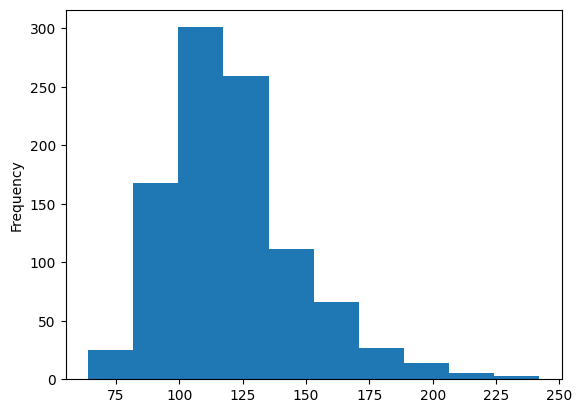

In [81]:
# 对 Series 进行绘图，且不使用 matplotlib

%matplotlib inline
# this code can let pandas show the plot,or pandas can just tell us about it in words 

data.duration.plot(kind = 'hist')
# kind = 'hist' means to show us 直方图

<Axes: xlabel='genre'>

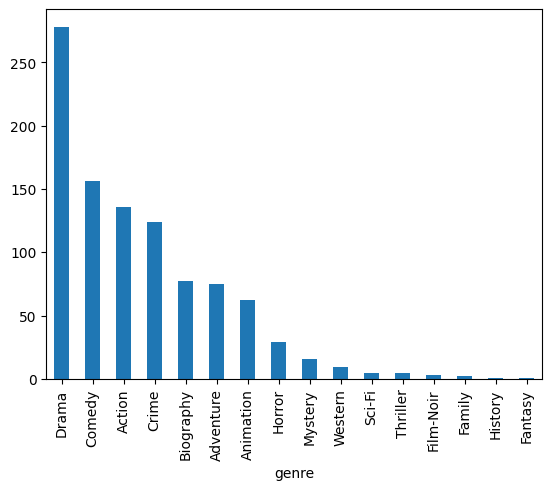

In [83]:
data.genre.value_counts().plot(kind = 'bar')

# Deal with Null Values

In [84]:
import pandas as pd
data = pd.read_csv('ufo.csv')
# when meet null,fill it with 'NaN'
data

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00
3,Abilene,NaN,DISK,KS,6/1/1931 13:00
4,New York Worlds Fair,NaN,LIGHT,NY,4/18/1933 19:00
...,...,...,...,...,...
18236,Grant Park,NaN,TRIANGLE,IL,12/31/2000 23:00
18237,Spirit Lake,NaN,DISK,IA,12/31/2000 23:00
18238,Eagle River,NaN,NaN,WI,12/31/2000 23:45
18239,Eagle River,RED,LIGHT,WI,12/31/2000 23:45


## isnull & notnull

In [85]:
data.isnull()
# is null print True(bool)

,City,Colors Reported,Shape Reported,State,Time
0,False,True,False,False,False
1,False,True,False,False,False
2,False,True,False,False,False
3,False,True,False,False,False
4,False,True,False,False,False
...,...,...,...,...,...
18236,False,True,False,False,False
18237,False,True,False,False,False
18238,False,True,True,False,False
18239,False,False,False,False,False


In [86]:
data.notnull()
# not null print True(bool)

,City,Colors Reported,Shape Reported,State,Time
0,True,False,True,True,True
1,True,False,True,True,True
2,True,False,True,True,True
3,True,False,True,True,True
4,True,False,True,True,True
...,...,...,...,...,...
18236,True,False,True,True,True
18237,True,False,True,True,True
18238,True,False,False,True,True
18239,True,True,True,True,True


In [87]:
data.isnull().sum()
# how much NaN is in each column

City                  26
Colors Reported    15359
Shape Reported      2644
State                  0
Time                   0
dtype: int64

In [89]:
# sum() can turn True into 1 while False into 0, then summary all the 1
pd.Series([True,False,True]).sum()

np.int64(2)

In [90]:
data.City.isnull()
# print a bool list 

0        False
1        False
2        False
3        False
4        False
         ...  
18236    False
18237    False
18238    False
18239    False
18240    False
Name: City, Length: 18241, dtype: bool

In [91]:
data[data.City.isnull()]
# select and show rows with City column being NaN

,City,Colors Reported,Shape Reported,State,Time
21,NaN,NaN,NaN,LA,8/15/1943 0:00
22,NaN,NaN,LIGHT,LA,8/15/1943 0:00
204,NaN,NaN,DISK,CA,7/15/1952 12:30
241,NaN,BLUE,DISK,MT,7/4/1953 14:00
613,NaN,NaN,DISK,NV,7/1/1960 12:00
1877,NaN,YELLOW,CIRCLE,AZ,8/15/1969 1:00
2013,NaN,NaN,NaN,NH,8/1/1970 9:30
2546,NaN,NaN,FIREBALL,OH,10/25/1973 23:30
3123,NaN,RED,TRIANGLE,WV,11/25/1975 23:00
4736,NaN,NaN,SPHERE,CA,6/23/1982 23:00


In [92]:
data[data.City.notnull()]
# select and show rows without City column being NaN

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00
3,Abilene,NaN,DISK,KS,6/1/1931 13:00
4,New York Worlds Fair,NaN,LIGHT,NY,4/18/1933 19:00
...,...,...,...,...,...
18236,Grant Park,NaN,TRIANGLE,IL,12/31/2000 23:00
18237,Spirit Lake,NaN,DISK,IA,12/31/2000 23:00
18238,Eagle River,NaN,NaN,WI,12/31/2000 23:45
18239,Eagle River,RED,LIGHT,WI,12/31/2000 23:45


# Index

In [57]:
import pandas as pd
data = pd.read_csv('ufo.csv')
data

,City,Colors Reported,Shape Reported,State,Time
0,Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
1,Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
2,Holyoke,NaN,OVAL,CO,2/15/1931 14:00
3,Abilene,NaN,DISK,KS,6/1/1931 13:00
4,New York Worlds Fair,NaN,LIGHT,NY,4/18/1933 19:00
...,...,...,...,...,...
18236,Grant Park,NaN,TRIANGLE,IL,12/31/2000 23:00
18237,Spirit Lake,NaN,DISK,IA,12/31/2000 23:00
18238,Eagle River,NaN,NaN,WI,12/31/2000 23:45
18239,Eagle River,RED,LIGHT,WI,12/31/2000 23:45


## Identification

In [58]:
# Index refer to row label
# being identifications , it won't change
# but cannot be a part of DF,saying it isnot a column
data.index

RangeIndex(start=0, stop=18241, step=1)

In [59]:
# Columns refer to column label
# index cannot be a part of DF,saying it isnot a column
data.columns

Index(['City', 'Colors Reported', 'Shape Reported', 'State', 'Time'], dtype='object')

## Selection

In [67]:
import pandas as pd
data = pd.read_csv('ufo.csv')

# we can set a column to be index
# but the column being setted will not be a part of DF anymore
data.set_index('City',inplace = True)
data

,Colors Reported,Shape Reported,State,Time
City,,,,
Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
Holyoke,NaN,OVAL,CO,2/15/1931 14:00
Abilene,NaN,DISK,KS,6/1/1931 13:00
New York Worlds Fair,NaN,LIGHT,NY,4/18/1933 19:00
...,...,...,...,...
Grant Park,NaN,TRIANGLE,IL,12/31/2000 23:00
Spirit Lake,NaN,DISK,IA,12/31/2000 23:00
Eagle River,NaN,NaN,WI,12/31/2000 23:45


In [73]:
data.dtypes

Colors Reported    object
Shape Reported     object
State              object
Time               object
dtype: object

In [76]:
# we can select Abilene's Colors Reported
data.loc['Abilene','Colors Reported']

City
Abilene    NaN
Abilene    NaN
Abilene    NaN
Abilene    NaN
Abilene    NaN
Name: Colors Reported, dtype: object

## Alignment

In [77]:
# 对齐
import pandas as pd

s1 = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
s2 = pd.Series([4, 5, 6], index=['b', 'c', 'd'])

print(s1)
print(s2)

a    1
b    2
c    3
dtype: int64
b    4
c    5
d    6
dtype: int64


In [78]:
print(s1 + s2)

a    NaN
b    6.0
c    8.0
d    NaN
dtype: float64


s1+s2: pandas 将索引 a, b, c, d 全部取并集，然后根据索引进行对齐：  
- 索引 a：只在 s1 中有值，s2 中没有 → 结果为 NaN  
- 索引 b：s1 中是 2，s2 中是 4 → 结果为 6   
- 索引 c：s1 中是 3，s2 中是 5 → 结果为 8   
- 索引 d：只在 s2 中有值，s1 中没有 → 结果为 NaN

这正是索引的对齐功能。它确保数据在运算时是基于标签匹配的，而不是依赖于数据在序列中的物理顺序。  
即使两个数据集的顺序不同，只要索引标签一致，pandas 就能正确对齐。

## Columns in index

### 重命名index

In [80]:
data.index.name = None
data

,Colors Reported,Shape Reported,State,Time
Ithaca,NaN,TRIANGLE,NY,6/1/1930 22:00
Willingboro,NaN,OTHER,NJ,6/30/1930 20:00
Holyoke,NaN,OVAL,CO,2/15/1931 14:00
Abilene,NaN,DISK,KS,6/1/1931 13:00
New York Worlds Fair,NaN,LIGHT,NY,4/18/1933 19:00
...,...,...,...,...
Grant Park,NaN,TRIANGLE,IL,12/31/2000 23:00
Spirit Lake,NaN,DISK,IA,12/31/2000 23:00
Eagle River,NaN,NaN,WI,12/31/2000 23:45
Eagle River,RED,LIGHT,WI,12/31/2000 23:45
